# 01 - EDA and data quality pass

The point of this pass is not pretty plots. It is to answer the questions that
change every downstream modeling choice, and to write each answer into
`docs/assumptions_limitations.md` the moment it is settled:

1. How rare is the positive class, and how is it distributed across athletes?
2. What does the `Date` axis actually mean (calendar time vs each athlete's tenure)?
   This decides whether a time-aware split is even well defined.
3. Where is the missingness, and does a zero mean "rested" or "not logged"? This
   decision shapes every feature in notebook 02.
4. What is the window/lag structure of a row, and does the row include the injury day?
5. What is NOT in the data that the evaluation plan assumes is (e.g. sex for subgroups)?

Decisions that a reviewer would expect me to defend are called out in **DECISION**
cells rather than buried in code.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')
pd.set_option('display.width', 120)
sorted(p.name for p in RAW.glob('*'))

['day_approach_maskedID_timeseries.csv.gz',
 'week_approach_maskedID_timeseries.csv.gz']

In [2]:
day  = pd.read_csv(RAW / 'day_approach_maskedID_timeseries.csv.gz')
week = pd.read_csv(RAW / 'week_approach_maskedID_timeseries.csv.gz')
print('day  approach:', day.shape)
print('week approach:', week.shape)
day.head(3)

day  approach: (42766, 73)
week approach: (42798, 72)


,nr. sessions,total km,km Z3-4,km Z5-T1-T2,km sprinting,strength training,hours alternative,perceived exertion,perceived trainingSuccess,perceived recovery,...,km Z5-T1-T2.6,km sprinting.6,strength training.6,hours alternative.6,perceived exertion.6,perceived trainingSuccess.6,perceived recovery.6,Athlete ID,injury,Date
0,1.0,5.8,0.0,0.6,1.2,0.0,0.0,0.11,0.00,0.18,...,0.0,0.0,0.0,1.0,0.10,0.00,0.15,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,...,0.5,1.2,0.0,0.0,0.10,0.00,0.17,0,0,1
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.10,0.00,0.17,...,0.0,0.0,0.0,0.0,-0.01,-0.01,-0.01,0,0,2


### The two framings

Both tables are already **sliding windows**, one row per prediction point, not raw
daily logs:

- **day approach** - 10 metrics (`nr. sessions`, `total km`, km by intensity zone,
  strength, alternative hours, and three subjective 0-1 scores) repeated 7 times.
  Ordering (proven in section 5, not assumed): the `.6` block is the **most recent
  day** and the unsuffixed block is the **oldest** (6 days back). New data enters at
  `.6` and ages toward the unsuffixed slot. Plus `Athlete ID`, `injury`, `Date`.
- **week approach** - 22 weekly aggregates repeated 3 times (this week, `.1`, `.2`),
  plus three week-over-week relative-load ratios, `Athlete ID`, `injury`, `Date`.

Same underlying logs, two feature framings. I lead with the day approach because it
has finer resolution; the week approach is the closer match to the paper's headline
model and gets used for benchmark comparison.

## 1. Class balance - how rare is an injury row?

In [3]:
for name, df in [('day', day), ('week', week)]:
    n, pos = len(df), int(df.injury.sum())
    print(f'{name:>4}: {n:>6} rows, {pos:>4} positive ({100*pos/n:.2f}%), '
          f'1 positive per ~{n/pos:.0f} rows')

 day:  42766 rows,  583 positive (1.36%), 1 positive per ~73 rows
week:  42798 rows,  575 positive (1.34%), 1 positive per ~74 rows


injuries per athlete: min 0, median 5, mean 7.9, max 35
athletes with 0 injury rows: 11 of 74


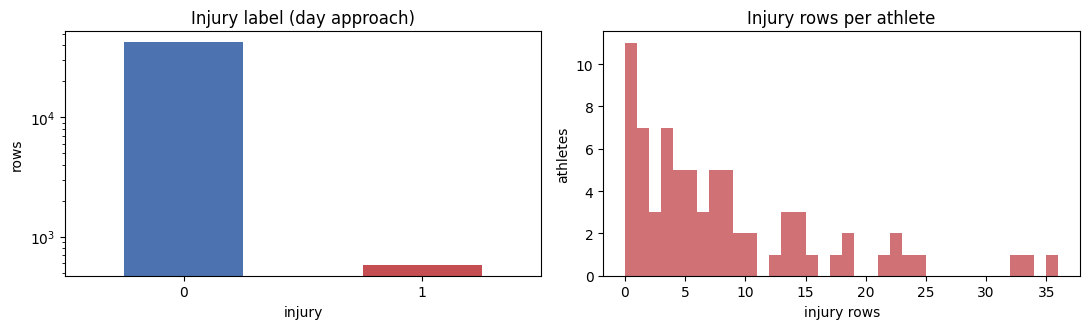

In [4]:
# Per-athlete injury counts (day approach)
inj_per = day.groupby('Athlete ID').injury.sum()
print('injuries per athlete: min %d, median %.0f, mean %.1f, max %d'
      % (inj_per.min(), inj_per.median(), inj_per.mean(), inj_per.max()))
print('athletes with 0 injury rows:', int((inj_per == 0).sum()), 'of', day['Athlete ID'].nunique())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
day.injury.value_counts().plot.bar(ax=ax[0], color=['#4C72B0', '#C44E52'])
ax[0].set_title('Injury label (day approach)'); ax[0].set_xlabel('injury'); ax[0].set_ylabel('rows')
ax[0].set_yscale('log'); ax[0].tick_params(axis='x', rotation=0)
ax[1].hist(inj_per.values, bins=range(0, inj_per.max() + 2), color='#C44E52', alpha=.8)
ax[1].set_title('Injury rows per athlete'); ax[1].set_xlabel('injury rows'); ax[1].set_ylabel('athletes')
plt.tight_layout()

**Finding.** ~1.36% positive rate (583/42,766 day rows). This is the rare-event
regime the whole evaluation plan is built around - accuracy is meaningless here, and
ROC will look flattering, which is exactly why `docs/evaluation_design.md` makes
precision-recall / average precision the headline.

**Finding (consequence for splits).** 11 of 74 athletes have **zero** injury rows.
An athlete-grouped test fold that happens to draw mostly zero-injury athletes will
have almost no positives and a near-undefined precision-recall curve. The grouped
evaluation has to report positive counts per fold, not just averaged metrics, or it
will quietly lie.

## 2. Athlete heterogeneity

rows per athlete: min 43, median 426, max 1791
the median athlete has ~4x fewer rows than the max
per-athlete injury RATE: min 0.000%, median 1.024%, max 4.521%


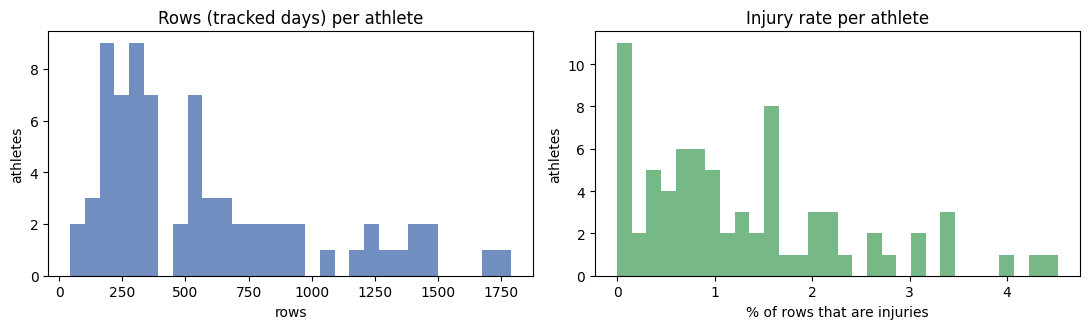

In [5]:
rows_per = day.groupby('Athlete ID').size()
print('rows per athlete: min %d, median %.0f, max %d' % (rows_per.min(), rows_per.median(), rows_per.max()))
print('the median athlete has ~%.0fx fewer rows than the max' % (rows_per.max() / rows_per.median()))

# injury RATE per athlete, not just count - some athletes are just tracked longer
rate_per = (inj_per / rows_per).sort_values()
print('per-athlete injury RATE: min %.3f%%, median %.3f%%, max %.3f%%'
      % (100*rate_per.min(), 100*rate_per.median(), 100*rate_per.max()))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(rows_per.values, bins=30, color='#4C72B0', alpha=.8)
ax[0].set_title('Rows (tracked days) per athlete'); ax[0].set_xlabel('rows'); ax[0].set_ylabel('athletes')
ax[1].hist(100*rate_per.values, bins=30, color='#55A868', alpha=.8)
ax[1].set_title('Injury rate per athlete'); ax[1].set_xlabel('% of rows that are injuries'); ax[1].set_ylabel('athletes')
plt.tight_layout()

**Finding.** Enormous heterogeneity in exposure (43 to 1,791 rows per athlete) and in
per-athlete injury rate. Athletes are not exchangeable. Two implications:

- A model can score well just by learning *which athlete* a row belongs to. Features
  must be within-athlete / relative where possible (notebook 02), and the grouped
  split is what actually tests whether it generalizes to a new runner.
- Long-tracked athletes dominate a plain row count. Any per-athlete claim needs the
  small-n caveat attached.

## 3. What is `Date`? Calendar time or per-athlete tenure?

`Date` is an integer. The time-aware split ("train early years, test later") only
means something if `Date` is a shared calendar. If instead it counted each athlete's
own days-since-enrollment, then "Date 100" would be different real dates for
different athletes and a time split would be incoherent. So this has to be checked,
not assumed.

In [6]:
print('Date dtype:', day.Date.dtype, '| range:', day.Date.min(), '..', day.Date.max(),
      '(~%.1f years if daily)' % ((day.Date.max() - day.Date.min()) / 365))

# If Date is a shared calendar, many athletes share each Date value.
per_date = day.groupby('Date')['Athlete ID'].nunique()
print('distinct Date values:', day.Date.nunique())
print('athletes sharing a given Date value: mean %.1f, max %d' % (per_date.mean(), per_date.max()))

starts = day.groupby('Athlete ID').Date.min()
print('athletes whose first Date <= 10:', int((starts <= 10).sum()), 'of 74',
      '(staggered enrollment, not everyone from day 0)')

Date dtype: int64 | range: 0 .. 2673 (~7.3 years if daily)
distinct Date values: 2614
athletes sharing a given Date value: mean 16.4, max 35
athletes whose first Date <= 10: 35 of 74 (staggered enrollment, not everyone from day 0)


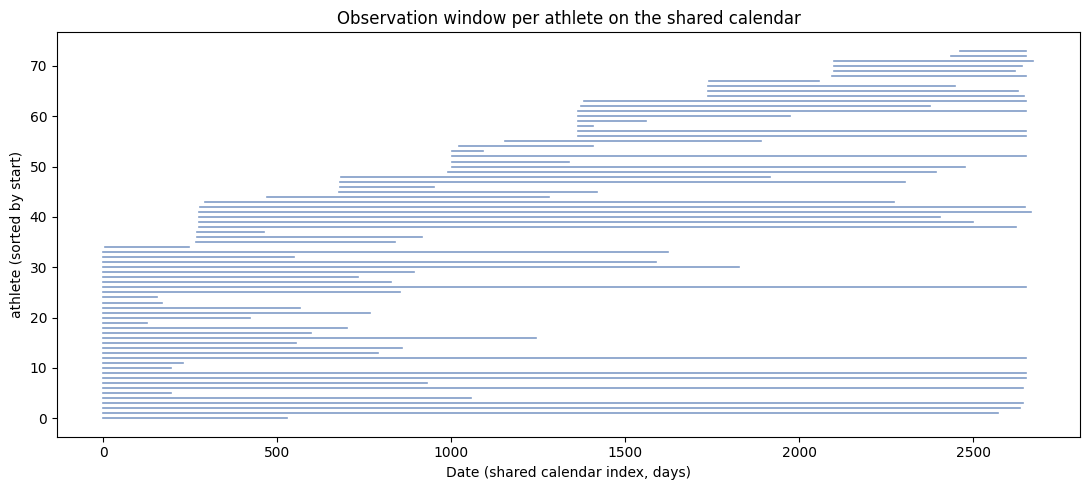

In [7]:
# Athlete enrollment/observation spans on a shared calendar axis
spans = day.groupby('Athlete ID').Date.agg(['min', 'max']).sort_values('min')
fig, ax = plt.subplots(figsize=(11, 5))
for i, (aid, r) in enumerate(spans.iterrows()):
    ax.plot([r['min'], r['max']], [i, i], color='#4C72B0', lw=1.2, alpha=.7)
ax.set_xlabel('Date (shared calendar index, days)'); ax.set_ylabel('athlete (sorted by start)')
ax.set_title('Observation window per athlete on the shared calendar')
plt.tight_layout()

**DECISION / finding - `Date` is a shared calendar index.** On average ~16 athletes
share each `Date` value (max 35), and enrollment is staggered rather than all-at-once.
So a time-aware split on a global `Date` cutoff is well defined: "train on rows up to
day T, test after." It also means athletes drop in and out, so a late-period test set
is a different athlete mix than the early-period train set - a caveat to state, and a
second reason to also run the athlete-grouped split.

Logged in `docs/assumptions_limitations.md`. (Note: `Date` has no year-0 anchor to a
real calendar and I will not invent one; relative ordering is all the split needs.)

## 4. Missingness: NaNs, zeros, and gaps between rows

The scaffold's open question: are missing days "no training" or "not logged"? There
are two distinct places a gap could hide - empty cells inside a row, and missing
rows on the calendar. Check both.

In [8]:
print('total NaN cells, day table :', int(day.isna().sum().sum()))
print('total NaN cells, week table:', int(week.isna().sum().sum()))

total NaN cells, day table : 0
total NaN cells, week table: 0


In [9]:
# Zero structure on the most-recent day slice (unsuffixed block)
base = ['nr. sessions','total km','km Z3-4','km Z5-T1-T2','km sprinting',
        'strength training','hours alternative','perceived exertion',
        'perceived trainingSuccess','perceived recovery']
print('zero-fraction on the most-recent-day slice:')
for col in base:
    print('  %-26s %.3f' % (col, (day[col] == 0).mean()))

run = ['nr. sessions','total km','km Z3-4','km Z5-T1-T2','km sprinting']
rest_like = (day[run] == 0).all(axis=1)
print()
print('day-slices with all running metrics == 0: %.1f%%' % (100*rest_like.mean()))
sub = day[rest_like]
print('  ...of those, a perceived-exertion value is present (non-zero): %.1f%%'
      % (100*(sub['perceived exertion'] != 0).mean()))

zero-fraction on the most-recent-day slice:
  nr. sessions               0.268
  total km                   0.405
  km Z3-4                    0.890
  km Z5-T1-T2                0.867
  km sprinting               0.925
  strength training          0.886
  hours alternative          0.877
  perceived exertion         0.024
  perceived trainingSuccess  0.220
  perceived recovery         0.026

day-slices with all running metrics == 0: 26.8%
  ...of those, a perceived-exertion value is present (non-zero): 100.0%


step to next row within an athlete:
  == 1 day  (consecutive): 97.7%
  == 2-7 days            : 0.0%
  >  7 days  (real gap)  : 2.3%
  largest gap: 649 days


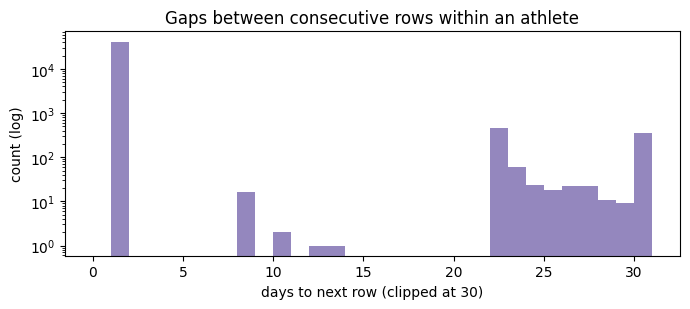

In [10]:
# Gaps BETWEEN consecutive rows within an athlete (the real 'unlogged' signal)
day_sorted = day.sort_values(['Athlete ID', 'Date'])
gaps = day_sorted.groupby('Athlete ID').Date.diff()
g = gaps.dropna()
print('step to next row within an athlete:')
print('  == 1 day  (consecutive): %.1f%%' % (100*(g == 1).mean()))
print('  == 2-7 days            : %.1f%%' % (100*g.between(2, 7).mean()))
print('  >  7 days  (real gap)  : %.1f%%' % (100*(g > 7).mean()))
print('  largest gap: %d days' % g.max())

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(np.clip(g.values, 0, 30), bins=range(0, 32), color='#8172B3', alpha=.85)
ax.set_yscale('log'); ax.set_xlabel('days to next row (clipped at 30)')
ax.set_ylabel('count (log)'); ax.set_title('Gaps between consecutive rows within an athlete')
plt.tight_layout()

**DECISION / finding - two different "missing", handled differently.**

- **No empty cells anywhere** (0 NaN in both tables). So there is no cell-level
  imputation problem. A `0` is a recorded value, not a hole.
- **A zero-km day is a logged rest/easy day, not an absent day.** On days where every
  running metric is 0, a perceived-exertion score is still present. The athlete was
  tracked that day and did not run - genuine rest, keep it as a real 0.
- **The actual "unlogged" gaps live between rows.** Most consecutive rows step 1 day,
  but a fraction jump by weeks (largest gap is months). Those gaps are periods with no
  row at all - off-season, injury layoff, or untracked time.

Why this matters downstream: rolling features in notebook 02 must not treat a
post-gap row as if the prior window were truly the preceding 7 calendar days. The
window is 7 *logged* days, which after a gap can span a long real interval. That is a
feature-construction caveat to carry forward, logged now so it is not rediscovered as
a bug later.

## 5. Window structure and lag ordering

In [11]:
# Prove the block ordering instead of assuming it. Claim: slot .6 is the most recent
# day and unsuffixed is the oldest, so for consecutive dates row(t).k == row(t-1).(k+1)
# (a fixed calendar day's value slides from .6 toward the unsuffixed slot as it ages).
base10 = ['nr. sessions','total km','km Z3-4','km Z5-T1-T2','km sprinting',
          'strength training','hours alternative','perceived exertion',
          'perceived trainingSuccess','perceived recovery']
checks = mism = 0
for _, a in day.groupby('Athlete ID'):
    a = a.sort_values('Date').reset_index(drop=True)
    dd = a.Date.values
    for i in range(1, len(a)):
        if dd[i] - dd[i-1] == 1:
            for c in base10:
                slots = [c] + [f'{c}.{k}' for k in range(1, 7)]
                for k in range(6):
                    checks += 1
                    mism += abs(a.loc[i, slots[k]] - a.loc[i-1, slots[k+1]]) > 1e-6
print(f'ordering check: {checks:,} comparisons, {mism} mismatches '
      f'-> .6 = most recent, unsuffixed = oldest (t-6): {"CONFIRMED" if mism==0 else "FAILED"}')

ordering check: 2,502,000 comparisons, 0 mismatches -> .6 = most recent, unsuffixed = oldest (t-6): CONFIRMED


In [12]:
# With ordering fixed, where does load sit around an injury? Slot .6 is the injury day.
cols = ['total km'] + [f'total km.{i}' for i in range(1, 7)]   # unsuffixed (oldest, t-6) ... .6 (injury day)
inj, non = day[day.injury == 1], day[day.injury == 0]
tbl = pd.DataFrame({'injury_rows': [inj[c].mean() for c in cols],
                    'non_injury' : [non[c].mean() for c in cols]},
                   index=['unsuffixed = t-6 (oldest)'] + [f'.{i} = t-{6-i}' for i in range(1, 7)])
print(tbl.round(2))

                           injury_rows  non_injury
unsuffixed = t-6 (oldest)         8.05        7.02
.1 = t-5                          6.45        7.03
.2 = t-4                          7.46        7.03
.3 = t-3                          7.16        7.04
.4 = t-2                          7.55        7.04
.5 = t-1                          7.95        7.04
.6 = t-0                          7.15        7.05


**Finding - block ordering proven, not assumed.** Across 2.5M value comparisons on
consecutive-date pairs there are zero mismatches with "the same calendar day's value
slides from `.6` toward the unsuffixed slot as it ages." So **`.6` is the most recent
day (the injury day on positive rows) and the unsuffixed block is the oldest (day
t-6)**. New data enters at `.6`.

On injury rows the load bump sits ~6 days *before* the event (the unsuffixed / oldest
slot is ~8.1 km vs a ~7.0 km flat baseline), while the injury day itself (`.6`) is near
baseline. That is a physiologically plausible "spike-then-break" shape, but it is one
noisy univariate slice, not a claim - the modeling notebooks test whether it holds up.

**DECISION for notebook 02/03 (flagging, not deciding here).** The `.6` block is the
injury day's own load. Predicting "injury today" from "today's load" is the paper's
framing and is fine for benchmark comparison, but for a *prospective* triage tool
("who is at risk going into tomorrow") the `.6` slice is not available yet. Whether to
drop the `.6` block, or keep it and label the task "same-day" honestly, is a modeling
choice for Austin. Noted in the assumptions log as open.

## 6. What the evaluation plan assumes but the data does not contain

In [13]:
for name, df in [('day', day), ('week', week)]:
    hits = [c for c in df.columns if any(k in c.lower() for k in ('sex','gender','female','male','age'))]
    print(f'{name:>4} approach - sex/age columns found:', hits or 'NONE')

 day approach - sex/age columns found: NONE
week approach - sex/age columns found: NONE


**Finding / DECISION - sex is not in the timeseries tables.** The evaluation design
calls for a subgroup check by sex, and the dataset is documented as 27 women / 47 men,
but neither table carries a sex or age column - only a masked `Athlete ID`. So the
subgroup-by-sex analysis is not runnable from these files alone.

Options for Austin (not resolving unilaterally):
1. Find an athlete-ID -> sex mapping in the source paper's replication package and
   join it in (keeps the subgroup check, adds a provenance step).
2. Drop the sex subgroup, keep tenure/exposure as the subgroup axis (which *is*
   derivable here), and say plainly in the README why sex was dropped.

Either way, `docs/evaluation_design.md`'s sex-subgroup line needs a footnote. Logged
as an open decision.

## Data-quality findings (carried into `docs/assumptions_limitations.md`)

| # | Finding | Downstream effect |
|---|---------|-------------------|
| 1 | 1.36% positive rate; 11/74 athletes have zero injuries | PR/AP headline; grouped folds must report positive counts |
| 2 | Athletes highly heterogeneous in exposure and injury rate | Prefer within-athlete features; grouped split is the real generalization test |
| 3 | `Date` is a shared calendar index with staggered enrollment | Time-aware split is well defined; train/test athlete mix differs |
| 4 | Zero NaN cells; zero-km = logged rest; gaps live between rows | No cell imputation; rolling windows are 7 *logged* days, not 7 calendar days |
| 5 | `.6` block = most recent day (the injury day); unsuffixed = oldest (t-6). Proven by 2.5M zero-mismatch slide checks | Open: keep same-day (`.6`) slice (paper framing) vs drop it (prospective framing) |
| 6 | No sex/age column in either table | Sex subgroup needs an external ID->sex join, or gets dropped with a stated reason |

Open decisions for Austin are flagged inline above (items 5 and 6, plus the sex
question). Everything else is settled and logged.